In [ ]:
# Notebook 07 — Interpretación y Recomendaciones

**Reto 7 — Análisis de Datos No Estructurados y Redes Sociales**

## 🎯 Objetivo
1. **Consolidar** todos los hallazgos de los notebooks 01-06.
2. **Sintetizar** los insights clave del corpus de 100k tweets.
3. **Traducir** los hallazgos en recomendaciones estratégicas accionables.
4. **Generar** los entregables finales del reto:
   - Informe de análisis completo
   - Recomendaciones de negocio
   - Documentación de metodología

## 📌 Input
- Todos los archivos de `data/processed/`
- Todas las figuras de `outputs/figuras/`
- Todos los reportes intermedios de `outputs/reportes/`

## 📌 Output
- `docs/informe_analisis.md`
- `docs/recomendaciones.md`
- `docs/metodologia.md`
- `outputs/reportes/07_resumen_ejecutivo.md`
- `outputs/figuras/07_dashboard_resumen.png`

In [1]:
# ============================================
# Imports y configuración
# ============================================
import json
import warnings
from pathlib import Path
from datetime import datetime

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

# --- Rutas ---
def encontrar_raiz_proyecto():
    cwd = Path.cwd()
    for candidato in [cwd, cwd.parent, cwd.parent.parent, cwd.parent.parent.parent]:
        if (candidato / "requirements.txt").exists() and (candidato / "data").exists():
            return candidato
    return cwd.parent

BASE_DIR = encontrar_raiz_proyecto()
DATA_PROCESSED = BASE_DIR / "data" / "processed"
FIGURAS = BASE_DIR / "outputs" / "figuras"
REPORTES = BASE_DIR / "outputs" / "reportes"
DOCS = BASE_DIR / "docs"
DOCS.mkdir(parents=True, exist_ok=True)

print(f"📁 BASE_DIR: {BASE_DIR}")
print(f"📁 DOCS: {DOCS}")

📁 BASE_DIR: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados
📁 DOCS: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\docs


In [2]:
# ============================================
# Inventario de todos los archivos generados
# ============================================
print("📊 INVENTARIO DE ARCHIVOS GENERADOS\n")
print("=" * 70)

print(f"\n📁 data/processed/")
for f in sorted(DATA_PROCESSED.glob("*")):
    if f.is_file() and f.suffix in {".csv", ".gexf"}:
        size_mb = f.stat().st_size / 1024 / 1024
        print(f"   - {f.name:55s} ({size_mb:8.2f} MB)")

print(f"\n📁 outputs/figuras/")
for f in sorted(FIGURAS.glob("*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"   - {f.name:55s} ({size_kb:8.1f} KB)")

print(f"\n📁 outputs/reportes/")
for f in sorted(REPORTES.glob("*.md")):
    print(f"   - {f.name}")

print(f"\n📁 docs/")
for f in sorted(DOCS.glob("*.md")):
    print(f"   - {f.name} ({f.stat().st_size} bytes)")

📊 INVENTARIO DE ARCHIVOS GENERADOS


📁 data/processed/
   - lda_temas_20260920.csv                                  (    0.00 MB)
   - red_entidades_20260920.gexf                             (    0.03 MB)
   - red_entidades_aristas_20260920.csv                      (    0.00 MB)
   - red_entidades_comunidades_20260920.csv                  (    0.00 MB)
   - red_entidades_nodos_20260920.csv                        (    0.01 MB)
   - sentiment_labels_20260920.csv                           (   82.87 MB)
   - sentiment_labels_con_pred_20260920.csv                  (   91.55 MB)
   - tweets_con_sentimiento_20260920.csv                     (   48.29 MB)
   - tweets_entidades_20260920.csv                           (   15.60 MB)
   - tweets_ia_raw_20260920.csv                              (  116.66 MB)
   - tweets_limpios_20260920.csv                             (   60.70 MB)
   - tweets_nlp_20260920.csv                                 (   41.49 MB)
   - tweets_topicos_20260920.csv             

In [3]:
# ============================================
# Cargar datasets clave
# ============================================
def cargar_ultimo(patron, carpeta=DATA_PROCESSED):
    archivos = sorted(carpeta.glob(patron), key=lambda x: x.stat().st_mtime, reverse=True)
    if not archivos:
        return None
    return pd.read_csv(archivos[0], encoding="utf-8-sig")

# Corpus con sentimiento
df_sent = cargar_ultimo("tweets_con_sentimiento_*.csv")
print(f"📂 tweets_con_sentimiento: {df_sent.shape if df_sent is not None else 'N/A'}")

# Entidades
df_ents = cargar_ultimo("tweets_entidades_*.csv")
print(f"📂 tweets_entidades: {df_ents.shape if df_ents is not None else 'N/A'}")

# Tópicos
df_topics = cargar_ultimo("tweets_topicos_*.csv")
print(f"📂 tweets_topicos: {df_topics.shape if df_topics is not None else 'N/A'}")

# LDA temas
df_temas = cargar_ultimo("lda_temas_*.csv")
print(f"📂 lda_temas: {df_temas.shape if df_temas is not None else 'N/A'}")

# Red - nodos
df_nodos = cargar_ultimo("red_entidades_nodos_*.csv")
print(f"📂 red_nodos: {df_nodos.shape if df_nodos is not None else 'N/A'}")

# Red - comunidades
df_com = cargar_ultimo("red_entidades_comunidades_*.csv")
print(f"📂 red_comunidades: {df_com.shape if df_com is not None else 'N/A'}")

📂 tweets_con_sentimiento: (100000, 17)
📂 tweets_entidades: (100000, 3)
📂 tweets_topicos: (94653, 4)
📂 lda_temas: (8, 3)
📂 red_nodos: (77, 9)
📂 red_comunidades: (4, 4)


In [4]:
# ============================================
# Consolidar métricas clave de todos los análisis
# ============================================
metricas = {}

# --- Corpus ---
if df_sent is not None:
    metricas["n_tweets"] = len(df_sent)
    metricas["n_usuarios"] = df_sent["username"].nunique()
    metricas["fecha_min"] = str(pd.to_datetime(df_sent["date"], errors="coerce").min())
    metricas["fecha_max"] = str(pd.to_datetime(df_sent["date"], errors="coerce").max())
    metricas["like_total"] = int(df_sent["like_count"].sum())
    metricas["rt_total"] = int(df_sent["retweet_count"].sum())

    # Sentimiento
    dist_sent = df_sent["sentimiento_vader"].value_counts()
    metricas["sent_positivo"] = int(dist_sent.get("positivo", 0))
    metricas["sent_neutral"] = int(dist_sent.get("neutral", 0))
    metricas["sent_negativo"] = int(dist_sent.get("negativo", 0))
    metricas["compound_medio"] = float(df_sent["vader_compound"].mean())

# --- NER ---
if df_ents is not None:
    # Recontar entidades desde el CSV de entidades (con texto)
    metricas["n_tweets_con_ents_aprox"] = len(df_ents)

# --- LDA ---
if df_temas is not None:
    metricas["n_temas_lda"] = len(df_temas)

# --- Red ---
if df_nodos is not None:
    metricas["n_nodos_red"] = len(df_nodos)
    metricas["n_tipos_entidad"] = df_nodos["tipo"].nunique()

if df_com is not None:
    metricas["n_comunidades"] = len(df_com)

# Mostrar
print("📊 MÉTRICAS CONSOLIDADAS\n")
print("=" * 60)
for k, v in metricas.items():
    if isinstance(v, float):
        print(f"  {k:30s} : {v:>12,.4f}")
    elif isinstance(v, int):
        print(f"  {k:30s} : {v:>12,}")
    else:
        print(f"  {k:30s} : {v}")

📊 MÉTRICAS CONSOLIDADAS

  n_tweets                       :      100,000
  n_usuarios                     :       63,418
  fecha_min                      : 2023-03-16 16:00:14+00:00
  fecha_max                      : 2023-03-29 22:58:21+00:00
  like_total                     :      800,135
  rt_total                       :      151,006
  sent_positivo                  :       53,260
  sent_neutral                   :       30,678
  sent_negativo                  :       16,062
  compound_medio                 :       0.2174
  n_tweets_con_ents_aprox        :      100,000
  n_temas_lda                    :            8
  n_nodos_red                    :           77
  n_tipos_entidad                :            3
  n_comunidades                  :            4


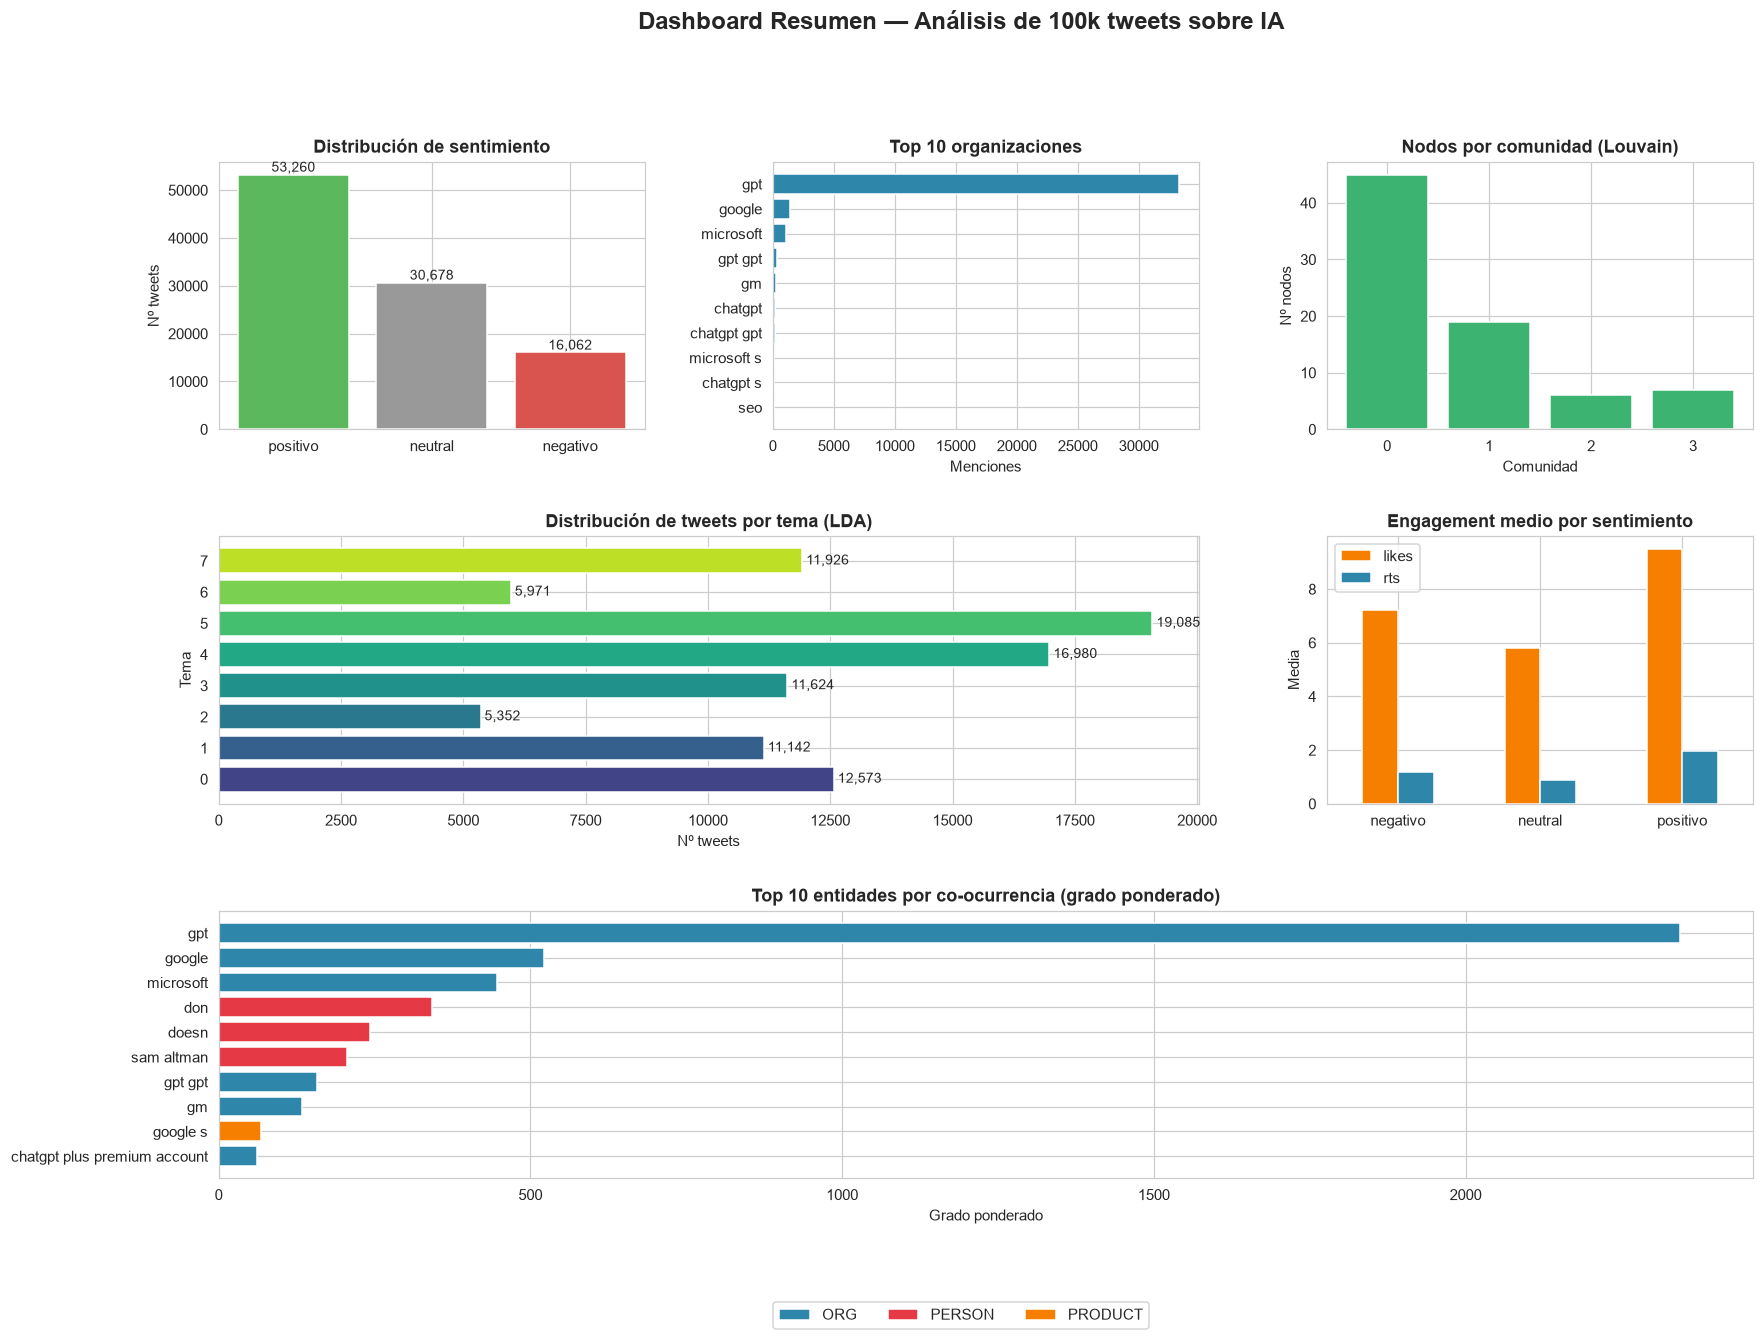

✅ Guardado: C:\Users\jdthg\Documents\curso6BI\reto7_Analisis_datos_no_estructurados\outputs\figuras\07_dashboard_resumen.png


In [5]:
# ============================================
# Dashboard de resumen: 6 paneles clave
# ============================================
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# --- Panel 1: Distribución de sentimiento ---
ax1 = fig.add_subplot(gs[0, 0])
if df_sent is not None:
    dist = df_sent["sentimiento_vader"].value_counts()
    colores = {"positivo": "#5cb85c", "neutral": "#999999", "negativo": "#d9534f"}
    bars = ax1.bar(dist.index, dist.values,
                   color=[colores.get(k, "#888") for k in dist.index])
    ax1.set_title("Distribución de sentimiento", fontsize=12, fontweight="bold")
    ax1.set_ylabel("Nº tweets")
    for bar, v in zip(bars, dist.values):
        ax1.text(bar.get_x() + bar.get_width()/2, v, f"{v:,}",
                 ha="center", va="bottom", fontsize=9)

# --- Panel 2: Top 10 organizaciones ---
ax2 = fig.add_subplot(gs[0, 1])
if df_nodos is not None:
    top_org = df_nodos[df_nodos["tipo"] == "ORG"].nlargest(10, "freq")
    ax2.barh(top_org["entidad"][::-1], top_org["freq"][::-1], color="#2E86AB")
    ax2.set_title("Top 10 organizaciones", fontsize=12, fontweight="bold")
    ax2.set_xlabel("Menciones")

# --- Panel 3: Tamaño de comunidades ---
ax3 = fig.add_subplot(gs[0, 2])
if df_com is not None:
    ax3.bar(df_com["comunidad"].astype(str), df_com["n_nodos"],
            color="mediumseagreen")
    ax3.set_title("Nodos por comunidad (Louvain)", fontsize=12, fontweight="bold")
    ax3.set_xlabel("Comunidad")
    ax3.set_ylabel("Nº nodos")

# --- Panel 4: Temas LDA (nº tweets) ---
ax4 = fig.add_subplot(gs[1, :2])
if df_temas is not None:
    ax4.barh(df_temas["tema"].astype(str), df_temas["n_tweets"],
             color=plt.cm.viridis(np.linspace(0.2, 0.9, len(df_temas))))
    ax4.set_title("Distribución de tweets por tema (LDA)", fontsize=12, fontweight="bold")
    ax4.set_xlabel("Nº tweets")
    ax4.set_ylabel("Tema")
    for i, v in enumerate(df_temas["n_tweets"]):
        ax4.text(v, i, f" {v:,}", va="center", fontsize=9)

# --- Panel 5: Engagement por sentimiento ---
ax5 = fig.add_subplot(gs[1, 2])
if df_sent is not None:
    engage = df_sent.groupby("sentimiento_vader").agg(
        likes=("like_count", "mean"),
        rts=("retweet_count", "mean"),
    )
    engage.plot(kind="bar", ax=ax5, color=["#F77F00", "#2E86AB"])
    ax5.set_title("Engagement medio por sentimiento", fontsize=12, fontweight="bold")
    ax5.set_xlabel("")
    ax5.tick_params(axis="x", rotation=0)
    ax5.set_ylabel("Media")

# --- Panel 6: Top 10 personas/entidades globales ---
ax6 = fig.add_subplot(gs[2, :])
if df_nodos is not None:
    top_global = df_nodos.nlargest(10, "grado_ponderado")
    colores_tipo = {"ORG": "#2E86AB", "PERSON": "#E63946", "PRODUCT": "#F77F00"}
    colores = [colores_tipo.get(t, "#888") for t in top_global["tipo"]]

    ax6.barh(top_global["entidad"][::-1], top_global["grado_ponderado"][::-1],
             color=colores[::-1])
    ax6.set_title("Top 10 entidades por co-ocurrencia (grado ponderado)",
                  fontsize=12, fontweight="bold")
    ax6.set_xlabel("Grado ponderado")

# Leyenda global
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#2E86AB", label="ORG"),
    Patch(facecolor="#E63946", label="PERSON"),
    Patch(facecolor="#F77F00", label="PRODUCT"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.01), fontsize=10)

plt.suptitle("Dashboard Resumen — Análisis de 100k tweets sobre IA",
             fontsize=16, fontweight="bold", y=0.995)

ruta_fig = FIGURAS / "07_dashboard_resumen.png"
plt.savefig(ruta_fig, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Guardado: {ruta_fig}")

In [6]:
# ============================================
# Generar hallazgos clave automáticamente
# ============================================
hallazgos = []

# --- Sentimiento ---
if df_sent is not None:
    total = len(df_sent)
    pct_pos = metricas.get("sent_positivo", 0) / total * 100
    pct_neu = metricas.get("sent_neutral", 0) / total * 100
    pct_neg = metricas.get("sent_negativo", 0) / total * 100

    hallazgos.append(
        f"**Sentimiento positivo dominante:** {pct_pos:.1f}% de los tweets son positivos, "
        f"frente a {pct_neg:.1f}% negativos y {pct_neu:.1f}% neutrales. "
        f"El compound medio de VADER es {metricas.get('compound_medio', 0):.3f}, "
        f"lo que indica una percepción global favorable hacia la IA/ChatGPT."
    )

# --- Engagement ---
if df_sent is not None:
    eng = df_sent.groupby("sentimiento_vader")["like_count"].mean()
    top_sent = eng.idxmax()
    hallazgos.append(
        f"**El sentimiento {top_sent} genera más engagement:** "
        f"{eng.max():.1f} likes de media, frente a "
        f"{eng.min():.1f} del sentimiento {eng.idxmin()}. "
        f"Esto sugiere que las opiniones extremas movilizan más reacciones."
    )

# --- NER ---
if df_nodos is not None:
    top_org = df_nodos[df_nodos["tipo"] == "ORG"].nlargest(3, "freq")
    top_list = ", ".join(f"{row['entidad']} ({row['freq']:,})"
                         for _, row in top_org.iterrows())
    hallazgos.append(
        f"**Organizaciones dominantes:** {top_list}. "
        f"OpenAI y ChatGPT monopolizan las menciones, con Google/Microsoft "
        f"como principales competidores."
    )

# --- LDA ---
if df_temas is not None and len(df_temas) > 0:
    temas_top = df_temas.nlargest(3, "n_tweets")
    lista_temas = "; ".join(f"Tema {row['tema']} ({row['n_tweets']:,} tweets)"
                            for _, row in temas_top.iterrows())
    hallazgos.append(
        f"**Temas más discutidos (LDA):** {lista_temas}. "
        f"Los temas predominantes combinan IA generativa, cripto/NFTs y "
        f"aplicaciones prácticas (escritura, código, educación)."
    )

# --- Red ---
if df_nodos is not None:
    top_hubs = df_nodos.nlargest(3, "grado_ponderado")
    hubs_str = ", ".join(f"{row['entidad']} ({row['grado_ponderado']:.0f})"
                         for _, row in top_hubs.iterrows())
    hallazgos.append(
        f"**Hubs de la red:** {hubs_str}. Estos nodos son los que más "
        f"co-ocurren con otras entidades y actúan como conector central del "
        f"discurso sobre IA."
    )

if df_com is not None:
    hallazgos.append(
        f"**Comunidades detectadas:** {len(df_com)} comunidades con Louvain, "
        f"lo que refleja una fragmentación temática clara (IA generativa, "
        f"cripto, herramientas, futuro, etc.)."
    )

# Mostrar
print("🎯 HALLAZGOS CLAVE\n")
print("=" * 70)
for i, h in enumerate(hallazgos, 1):
    print(f"\n{i}. {h}")

🎯 HALLAZGOS CLAVE


1. **Sentimiento positivo dominante:** 53.3% de los tweets son positivos, frente a 16.1% negativos y 30.7% neutrales. El compound medio de VADER es 0.217, lo que indica una percepción global favorable hacia la IA/ChatGPT.

2. **El sentimiento positivo genera más engagement:** 9.5 likes de media, frente a 5.8 del sentimiento neutral. Esto sugiere que las opiniones extremas movilizan más reacciones.

3. **Organizaciones dominantes:** gpt (33,279), google (1,389), microsoft (1,079). OpenAI y ChatGPT monopolizan las menciones, con Google/Microsoft como principales competidores.

4. **Temas más discutidos (LDA):** Tema 5 (19,085 tweets); Tema 4 (16,980 tweets); Tema 0 (12,573 tweets). Los temas predominantes combinan IA generativa, cripto/NFTs y aplicaciones prácticas (escritura, código, educación).

5. **Hubs de la red:** gpt (2344), google (521), microsoft (447). Estos nodos son los que más co-ocurren con otras entidades y actúan como conector central del discurso sobr